In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv("Enterprise_HRM_Categorical_Target.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (15000, 18)


,Employee_ID,Quarter,Age,Years_of_Experience,Department,Education_Level,Job_Level,Attendance_Rate,Absenteeism_Rate,Productivity_Score,Engagement_Score,Workload_Index,Training_Hours,Competency_Score,Collaboration_Score,Work_Quality_Score,Previous_Performance_Score,Performance_Category
0,E00001,1,30.98,11.76,Sales,PhD,Mid,93.46,7.29,72.37,67.24,49.04,21.67,71.65,55.92,72.67,61.26,High
1,E00001,2,30.98,11.76,Sales,PhD,Mid,90.35,9.67,58.76,70.19,73.35,28.10,72.84,69.14,62.58,75.11,Moderate
2,E00001,3,30.98,11.76,Sales,PhD,Mid,89.84,9.79,60.02,66.11,32.65,8.87,65.89,59.87,75.75,73.98,Moderate
3,E00001,4,30.98,11.76,Sales,PhD,Mid,89.14,11.23,72.60,72.88,70.53,18.88,69.52,81.46,69.97,71.92,Moderate
4,E00001,5,30.98,11.76,Sales,PhD,Mid,93.99,5.83,70.18,63.66,50.86,27.52,78.56,60.85,67.41,72.85,Moderate


In [2]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nDataset Information:")
df.info()

Missing Values:
Employee_ID                   0
Quarter                       0
Age                           0
Years_of_Experience           0
Department                    0
Education_Level               0
Job_Level                     0
Attendance_Rate               0
Absenteeism_Rate              0
Productivity_Score            0
Engagement_Score              0
Workload_Index                0
Training_Hours                0
Competency_Score              0
Collaboration_Score           0
Work_Quality_Score            0
Previous_Performance_Score    0
Performance_Category          0
dtype: int64

Duplicate Rows: 0

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Employee_ID                 15000 non-null  str    
 1   Quarter                     15000 non-null  int64  
 2   Age                    

In [3]:
print(df["Department"].value_counts())

Department
Research and Development    1965
Customer Service            1960
Finance                     1960
HR                          1920
Sales                       1870
Marketing                   1860
IT                          1760
Operations                  1705
Name: count, dtype: int64


In [5]:
print(df["Productivity_Score"].describe())

count    15000.000000
mean        68.706942
std          8.384005
min         39.360000
25%         62.980000
50%         68.700000
75%         74.510000
max         98.960000
Name: Productivity_Score, dtype: float64


In [6]:
dept_productivity = (
    df.groupby("Department")["Productivity_Score"]
      .agg(["count", "mean", "median", "std", "min", "max"])
      .sort_values("mean", ascending=False)
)

print(dept_productivity.round(2))

                          count   mean  median   std    min    max
Department                                                        
Finance                    1960  69.14   69.15  8.03  41.80  92.76
Research and Development   1965  68.81   68.90  8.42  42.36  95.30
IT                         1760  68.81   68.84  8.35  42.74  94.29
HR                         1920  68.78   68.72  8.51  43.27  97.21
Sales                      1870  68.58   68.53  8.44  41.90  94.82
Customer Service           1960  68.55   68.65  8.40  40.07  98.96
Marketing                  1860  68.54   68.47  8.49  40.58  94.20
Operations                 1705  68.40   68.38  8.43  39.36  94.85


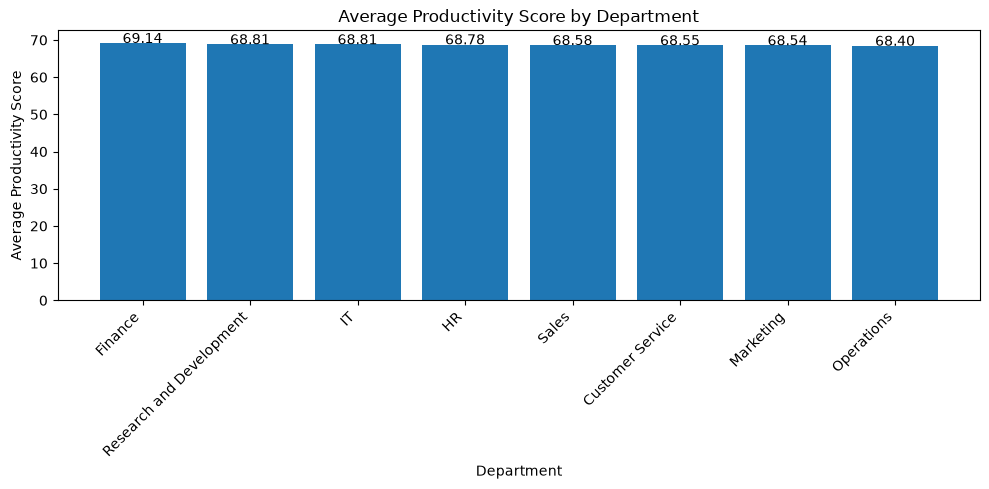

In [7]:
dept_avg = (
    df.groupby("Department")["Productivity_Score"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))

bars = plt.bar(dept_avg.index, dept_avg.values)

plt.title("Average Productivity Score by Department")
plt.xlabel("Department")
plt.ylabel("Average Productivity Score")
plt.xticks(rotation=45, ha="right")

for bar, value in zip(bars, dept_avg.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.05,
        f"{value:.2f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [8]:
performance_metrics = [
    "Productivity_Score",
    "Attendance_Rate",
    "Absenteeism_Rate",
    "Engagement_Score",
    "Workload_Index",
    "Training_Hours",
    "Competency_Score",
    "Collaboration_Score",
    "Work_Quality_Score",
    "Previous_Performance_Score"
]

department_metrics = (
    df.groupby("Department")[performance_metrics]
      .mean()
      .round(2)
)

print(department_metrics)

                          Productivity_Score  Attendance_Rate  \
Department                                                      
Customer Service                       68.55            90.86   
Finance                                69.14            90.86   
HR                                     68.78            90.81   
IT                                     68.81            90.76   
Marketing                              68.54            90.86   
Operations                             68.40            91.00   
Research and Development               68.81            90.79   
Sales                                  68.58            90.93   

                          Absenteeism_Rate  Engagement_Score  Workload_Index  \
Department                                                                     
Customer Service                      9.15             69.67           55.11   
Finance                               9.14             70.95           55.38   
HR                           

In [10]:
quarter_productivity = (
    df.groupby("Quarter")["Productivity_Score"]
      .agg(["count", "mean", "median", "std"])
)

print(quarter_productivity.round(2))

         count   mean  median   std
Quarter                            
1         3000  68.16   68.12  8.35
2         3000  68.65   68.57  8.36
3         3000  68.69   68.52  8.37
4         3000  69.02   69.17  8.40
5         3000  69.01   69.13  8.41


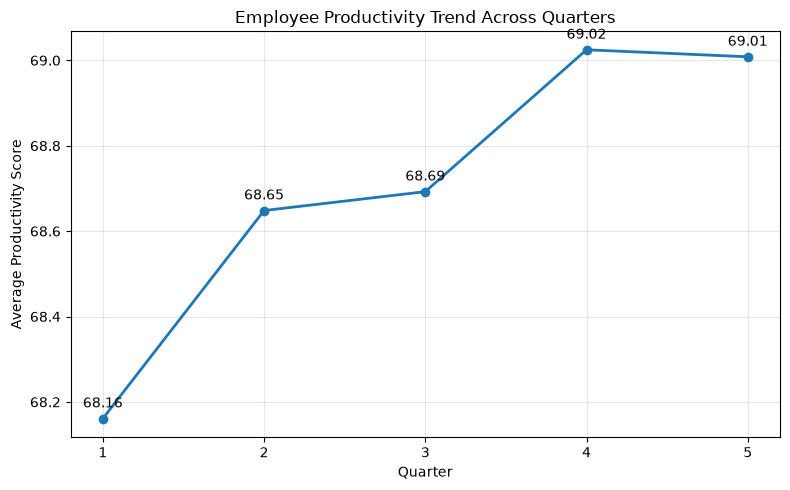

In [11]:
quarter_avg = df.groupby("Quarter")["Productivity_Score"].mean()

plt.figure(figsize=(8, 5))

plt.plot(
    quarter_avg.index,
    quarter_avg.values,
    marker="o",
    linewidth=2
)

plt.title("Employee Productivity Trend Across Quarters")
plt.xlabel("Quarter")
plt.ylabel("Average Productivity Score")
plt.xticks(quarter_avg.index)
plt.grid(True, alpha=0.3)

for q, value in quarter_avg.items():
    plt.annotate(
        f"{value:.2f}",
        (q, value),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center"
    )

plt.tight_layout()
plt.show()

In [12]:
dept_quarter = pd.pivot_table(
    df,
    index="Department",
    columns="Quarter",
    values="Productivity_Score",
    aggfunc="mean"
)

print(dept_quarter.round(2))

Quarter                       1      2      3      4      5
Department                                                 
Customer Service          67.95  68.19  68.40  69.46  68.77
Finance                   68.89  68.63  69.54  69.22  69.42
HR                        68.14  67.93  68.76  69.52  69.54
IT                        68.35  69.21  68.55  68.89  69.04
Marketing                 67.74  68.60  68.72  68.60  69.02
Operations                67.94  68.43  68.32  68.93  68.39
Research and Development  68.18  69.25  68.25  69.30  69.08
Sales                     68.05  68.96  68.95  68.21  68.72


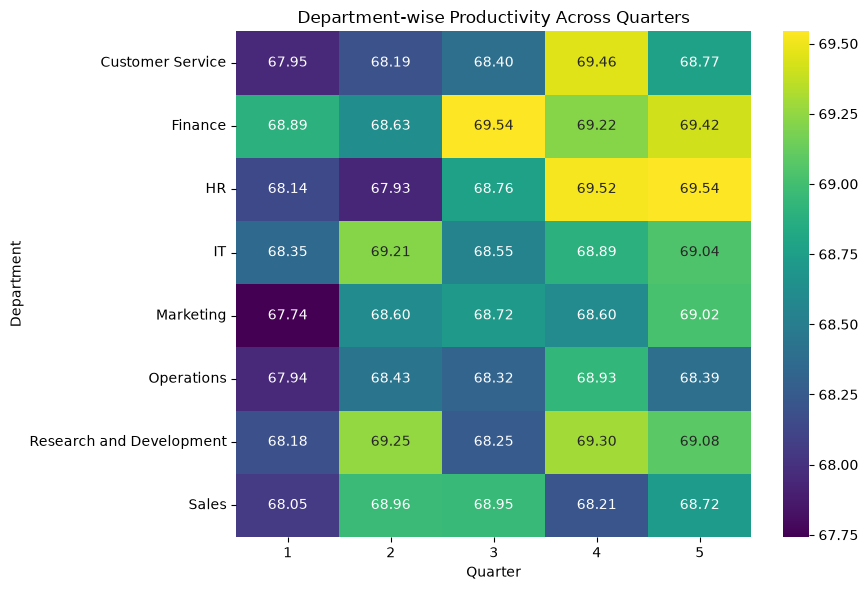

In [13]:
plt.figure(figsize=(9, 6))

sns.heatmap(
    dept_quarter,
    annot=True,
    fmt=".2f",
    cmap="viridis"
)

plt.title("Department-wise Productivity Across Quarters")
plt.xlabel("Quarter")
plt.ylabel("Department")
plt.tight_layout()
plt.show()

In [14]:
department_groups = [
    group["Productivity_Score"].values
    for _, group in df.groupby("Department")
]

anova_result = stats.f_oneway(*department_groups)

print("F-statistic:", anova_result.statistic)
print("p-value:", anova_result.pvalue)

F-statistic: 1.430323221418054
p-value: 0.1879741577537599


In [15]:
kruskal_result = stats.kruskal(*department_groups)

print("Kruskal-Wallis Statistic:", kruskal_result.statistic)
print("p-value:", kruskal_result.pvalue)

Kruskal-Wallis Statistic: 11.239606988424272
p-value: 0.1285035972975296


In [16]:
quarter_groups = [
    group["Productivity_Score"].values
    for _, group in df.groupby("Quarter")
]

quarter_anova = stats.f_oneway(*quarter_groups)

print("F-statistic:", quarter_anova.statistic)
print("p-value:", quarter_anova.pvalue)

F-statistic: 5.268807639293342
p-value: 0.00030785333258003276


In [17]:
employee_quarter = df.pivot(
    index="Employee_ID",
    columns="Quarter",
    values="Productivity_Score"
)

friedman_result = stats.friedmanchisquare(
    employee_quarter[1],
    employee_quarter[2],
    employee_quarter[3],
    employee_quarter[4],
    employee_quarter[5]
)

print("Friedman Statistic:", friedman_result.statistic)
print("p-value:", friedman_result.pvalue)

Friedman Statistic: 17.486571642916562
p-value: 0.0015543351091008935


In [18]:
from itertools import combinations
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

pairs = []
p_values = []

for q1, q2 in combinations([1, 2, 3, 4, 5], 2):
    result = wilcoxon(
        employee_quarter[q1],
        employee_quarter[q2]
    )

    pairs.append((q1, q2))
    p_values.append(result.pvalue)

adjusted = multipletests(
    p_values,
    method="holm"
)

results = pd.DataFrame({
    "Quarter_Comparison": pairs,
    "Raw_p_value": p_values,
    "Adjusted_p_value": adjusted[1],
    "Significant": adjusted[0]
})

print(results)

  Quarter_Comparison  Raw_p_value  Adjusted_p_value  Significant
0             (1, 2)     0.018749          0.135437        False
1             (1, 3)     0.016930          0.135437        False
2             (1, 4)     0.000009          0.000077         True
3             (1, 5)     0.000002          0.000023         True
4             (2, 3)     0.972598          1.000000        False
5             (2, 4)     0.064626          0.387753        False
6             (2, 5)     0.073124          0.387753        False
7             (3, 4)     0.116293          0.387753        False
8             (3, 5)     0.075699          0.387753        False
9             (4, 5)     0.746486          1.000000        False


In [19]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols(
    "Productivity_Score ~ C(Department) * C(Quarter)",
    data=df
).fit()

anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

                                sum_sq       df         F    PR(>F)
C(Department)             7.036361e+02      7.0  1.431423  0.187540
C(Quarter)                1.479726e+03      4.0  5.267922  0.000308
C(Department):C(Quarter)  1.577259e+03     28.0  0.802164  0.759408
Residual                  1.050542e+06  14960.0       NaN       NaN


In [20]:
numeric_performance = [
    "Productivity_Score",
    "Attendance_Rate",
    "Absenteeism_Rate",
    "Engagement_Score",
    "Workload_Index",
    "Training_Hours",
    "Competency_Score",
    "Collaboration_Score",
    "Work_Quality_Score",
    "Previous_Performance_Score"
]

correlation = (
    df[numeric_performance]
    .corr()["Productivity_Score"]
    .sort_values(ascending=False)
)

print(correlation.round(3))

Productivity_Score            1.000
Competency_Score              0.508
Work_Quality_Score            0.379
Previous_Performance_Score    0.310
Engagement_Score              0.202
Workload_Index                0.148
Attendance_Rate               0.136
Collaboration_Score           0.071
Training_Hours               -0.031
Absenteeism_Rate             -0.134
Name: Productivity_Score, dtype: float64
